# Phase 2. 정밀 전처리

**목적**: EDA 결과 + 도메인 조사를 반영하여 분석 가능한 최종 형태로 데이터를 정제한다.

**입력 데이터**: `data/processed/all_data.parquet` (16,868,714행)

**출력 데이터**: `data/processed/all_data_clean.parquet` (16,514,151행, 원본 스케일)

**실행 스크립트**: `scripts/phase2_preprocess.py` (메모리 효율을 위해 별도 스크립트로 실행)

**근거 문서**: `전처리방침.md`, `도메인조사.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

HOUR_COLS = [f'{i}시' for i in range(1, 25)]
FIG_DIR = '../outputs/figures'
PROCESSED_DIR = '../data/processed'
ARCHIVE_DIR = '../data/processed/archive'

# 전처리 요약 로드
with open(f'{PROCESSED_DIR}/phase2_summary.json', 'r', encoding='utf-8') as f:
    summary = json.load(f)
with open(f'{PROCESSED_DIR}/norm_params.json', 'r', encoding='utf-8') as f:
    norm_params = json.load(f)

print('Phase 2 전처리 요약 로드 완료')

Phase 2 전처리 요약 로드 완료


## 전처리 결과 요약

In [2]:
print('=' * 60)
print('Phase 2 전처리 처리 로그')
print('=' * 60)
for entry in summary['log']:
    print(f'  {entry}')
print(f'\n원본: {summary["initial_rows"]:,}행 -> 최종: {summary["final_rows"]:,}행 ({summary["preservation_rate"]}%)')

print(f'\n=== 품질 검증 ===')
checks = summary['checks']
print(f'[PASS] 시간당 음수값 잔존: {checks["neg_hourly"]}건')
print(f'[PASS] 시간당 NaN 잔존: {checks["nan_hourly"]}건')
print(f'[PASS] 총사용량 음수 잔존: {checks["neg_total"]}건')
print(f'[PASS] 보간 행 비율: {checks["interp_rate"]}%')
for t, d in checks['removal_rates'].items():
    print(f'[PASS] {t} 제거율: {d["rate"]}% ({d["original"]:,} -> {d["current"]:,})')

print(f'\n=== 극단값 threshold (시간당 99.9%ile) ===')
for t, th in summary['thresholds'].items():
    print(f'  {t}: {th} Gcal')

Phase 2 전처리 처리 로그
  냉수용 제외: -211,988행
  NaN 30%+ 설비 제외: -53,258행 (45개 설비)
  검침기 리셋 제거: -1,030행
  총사용량 음수 제거: -1,411행
  시간대 음수 clip: 4,667개 셀
  극단값 행 제거: -1,324행
  극단값 clip 완료
  NaN=24 행 제거: -60,341행
  NaN 4~23 행 제거: -25,211행
  NaN 1~3 보간: 88,566행

원본: 16,868,714행 -> 최종: 16,514,151행 (97.9%)

=== 품질 검증 ===
[PASS] 시간당 음수값 잔존: 0건
[PASS] 시간당 NaN 잔존: 0건
[PASS] 총사용량 음수 잔존: 0건
[PASS] 보간 행 비율: 0.536%
[PASS] 주택용 제거율: 0.54% (8,399,121 -> 8,353,530)
[PASS] 업무용 제거율: 1.16% (6,468,701 -> 6,393,706)
[PASS] 공공용 제거율: 1.23% (1,788,904 -> 1,766,915)

=== 극단값 threshold (시간당 99.9%ile) ===
  주택용: 2.59 Gcal
  업무용: 2.74 Gcal
  공공용: 4.38 Gcal


## NaN=24 분포 (DCU 장애 패턴)

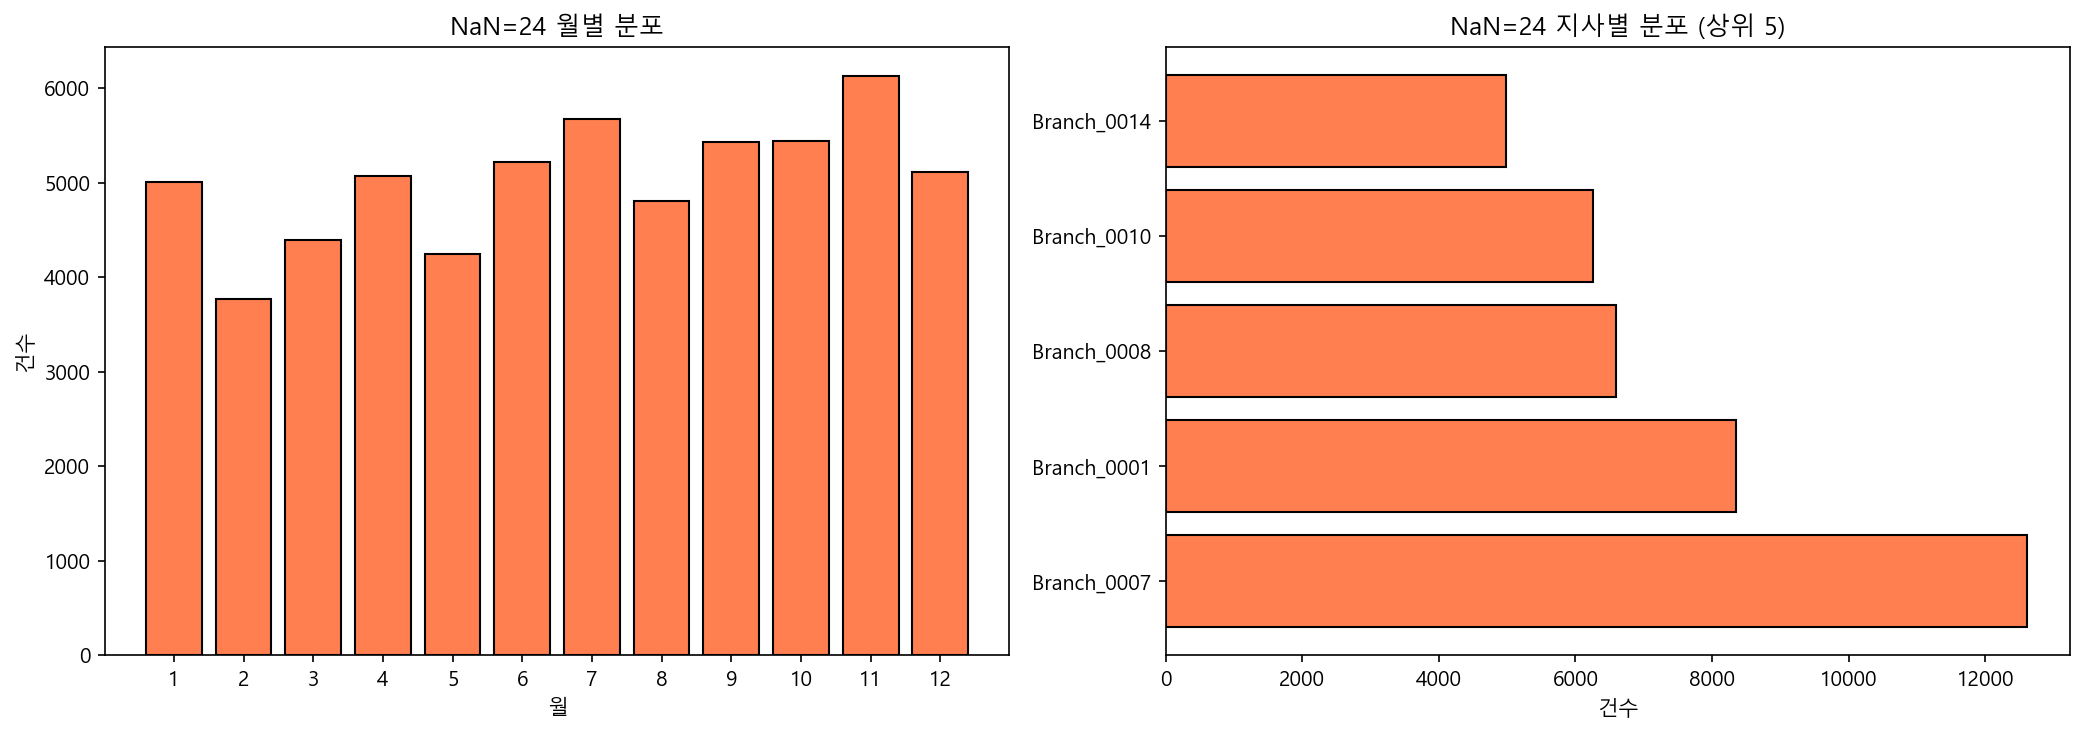

NaN=24 총 60,341건. Branch_0007이 최다 (12611건) -> DCU 장애 집중 지사


In [3]:
# NaN=24 월별 분포
nan24_m = summary['nan24_monthly']
nan24_b = summary['nan24_branch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

months = sorted(nan24_m.keys(), key=int)
axes[0].bar([int(m) for m in months], [nan24_m[m] for m in months], color='coral', edgecolor='black')
axes[0].set_title('NaN=24 월별 분포')
axes[0].set_xlabel('월')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(1, 13))

branches = list(nan24_b.keys())
axes[1].barh(branches, [nan24_b[b] for b in branches], color='coral', edgecolor='black')
axes[1].set_title('NaN=24 지사별 분포 (상위 5)')
axes[1].set_xlabel('건수')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase02_nan24_distribution.png', bbox_inches='tight')
plt.show()
print(f'NaN=24 총 {sum(nan24_m.values()):,}건. Branch_0007이 최다 ({nan24_b.get("Branch_0007", "N/A")}건) -> DCU 장애 집중 지사')

## 전처리 전후 시간대 평균 곡선 비교

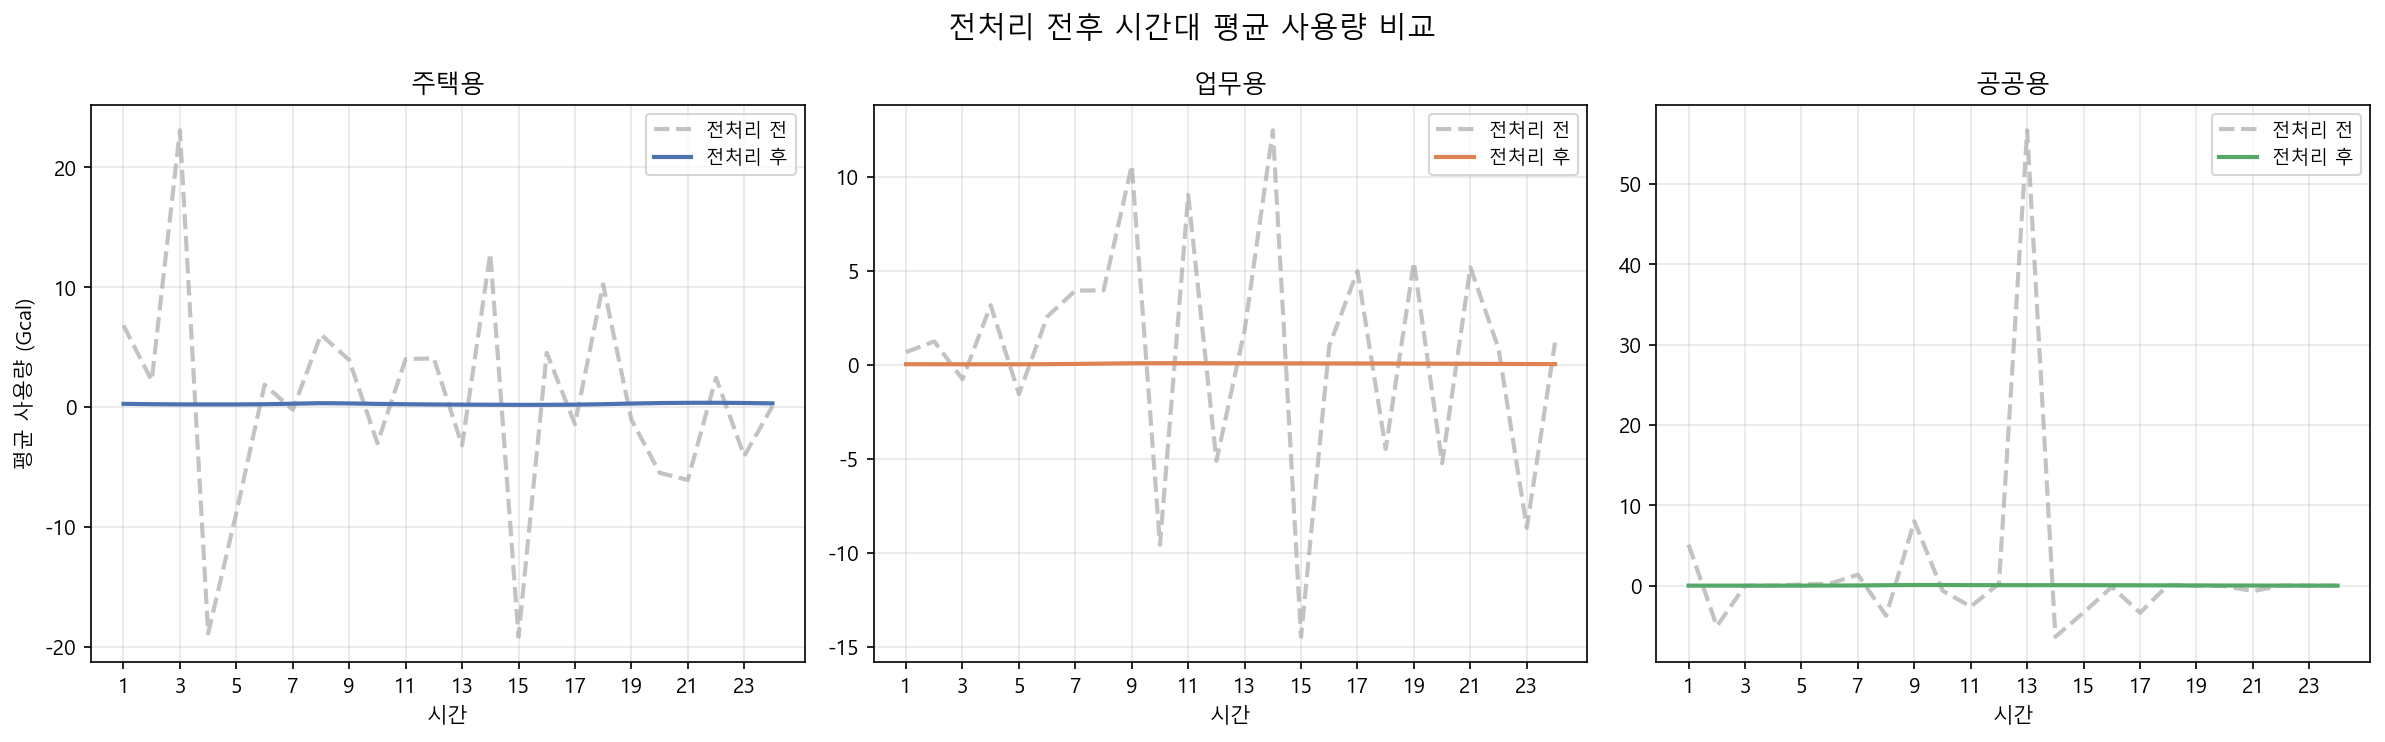

In [4]:
# 전처리 전 데이터 (archive)에서 시간대 평균만 추출
df_orig = pd.read_parquet(f'{ARCHIVE_DIR}/all_data_phase0.parquet', columns=['종별'] + HOUR_COLS)
before = {}
for t in ['주택용', '업무용', '공공용']:
    before[t] = df_orig[df_orig['종별'] == t][HOUR_COLS].mean().values
del df_orig

# 전처리 후 데이터
df = pd.read_parquet(f'{PROCESSED_DIR}/all_data_clean.parquet', columns=['종별'] + HOUR_COLS)
after = {}
for t in ['주택용', '업무용', '공공용']:
    after[t] = df[df['종별'] == t][HOUR_COLS].mean().values
del df

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'주택용': '#4C72B0', '업무용': '#DD8452', '공공용': '#55A868'}

for idx, t in enumerate(['주택용', '업무용', '공공용']):
    ax = axes[idx]
    ax.plot(range(1, 25), before[t], color='#AAAAAA', linewidth=2, linestyle='--', label='전처리 전', alpha=0.7)
    ax.plot(range(1, 25), after[t], color=colors[t], linewidth=2, label='전처리 후')
    ax.set_title(t)
    ax.set_xlabel('시간')
    if idx == 0:
        ax.set_ylabel('평균 사용량 (Gcal)')
    ax.set_xticks(range(1, 25, 2))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('전처리 전후 시간대 평균 사용량 비교', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase02_before_after_hourly.png', bbox_inches='tight')
plt.show()

## 정규화 분포 검증 (Z-score)

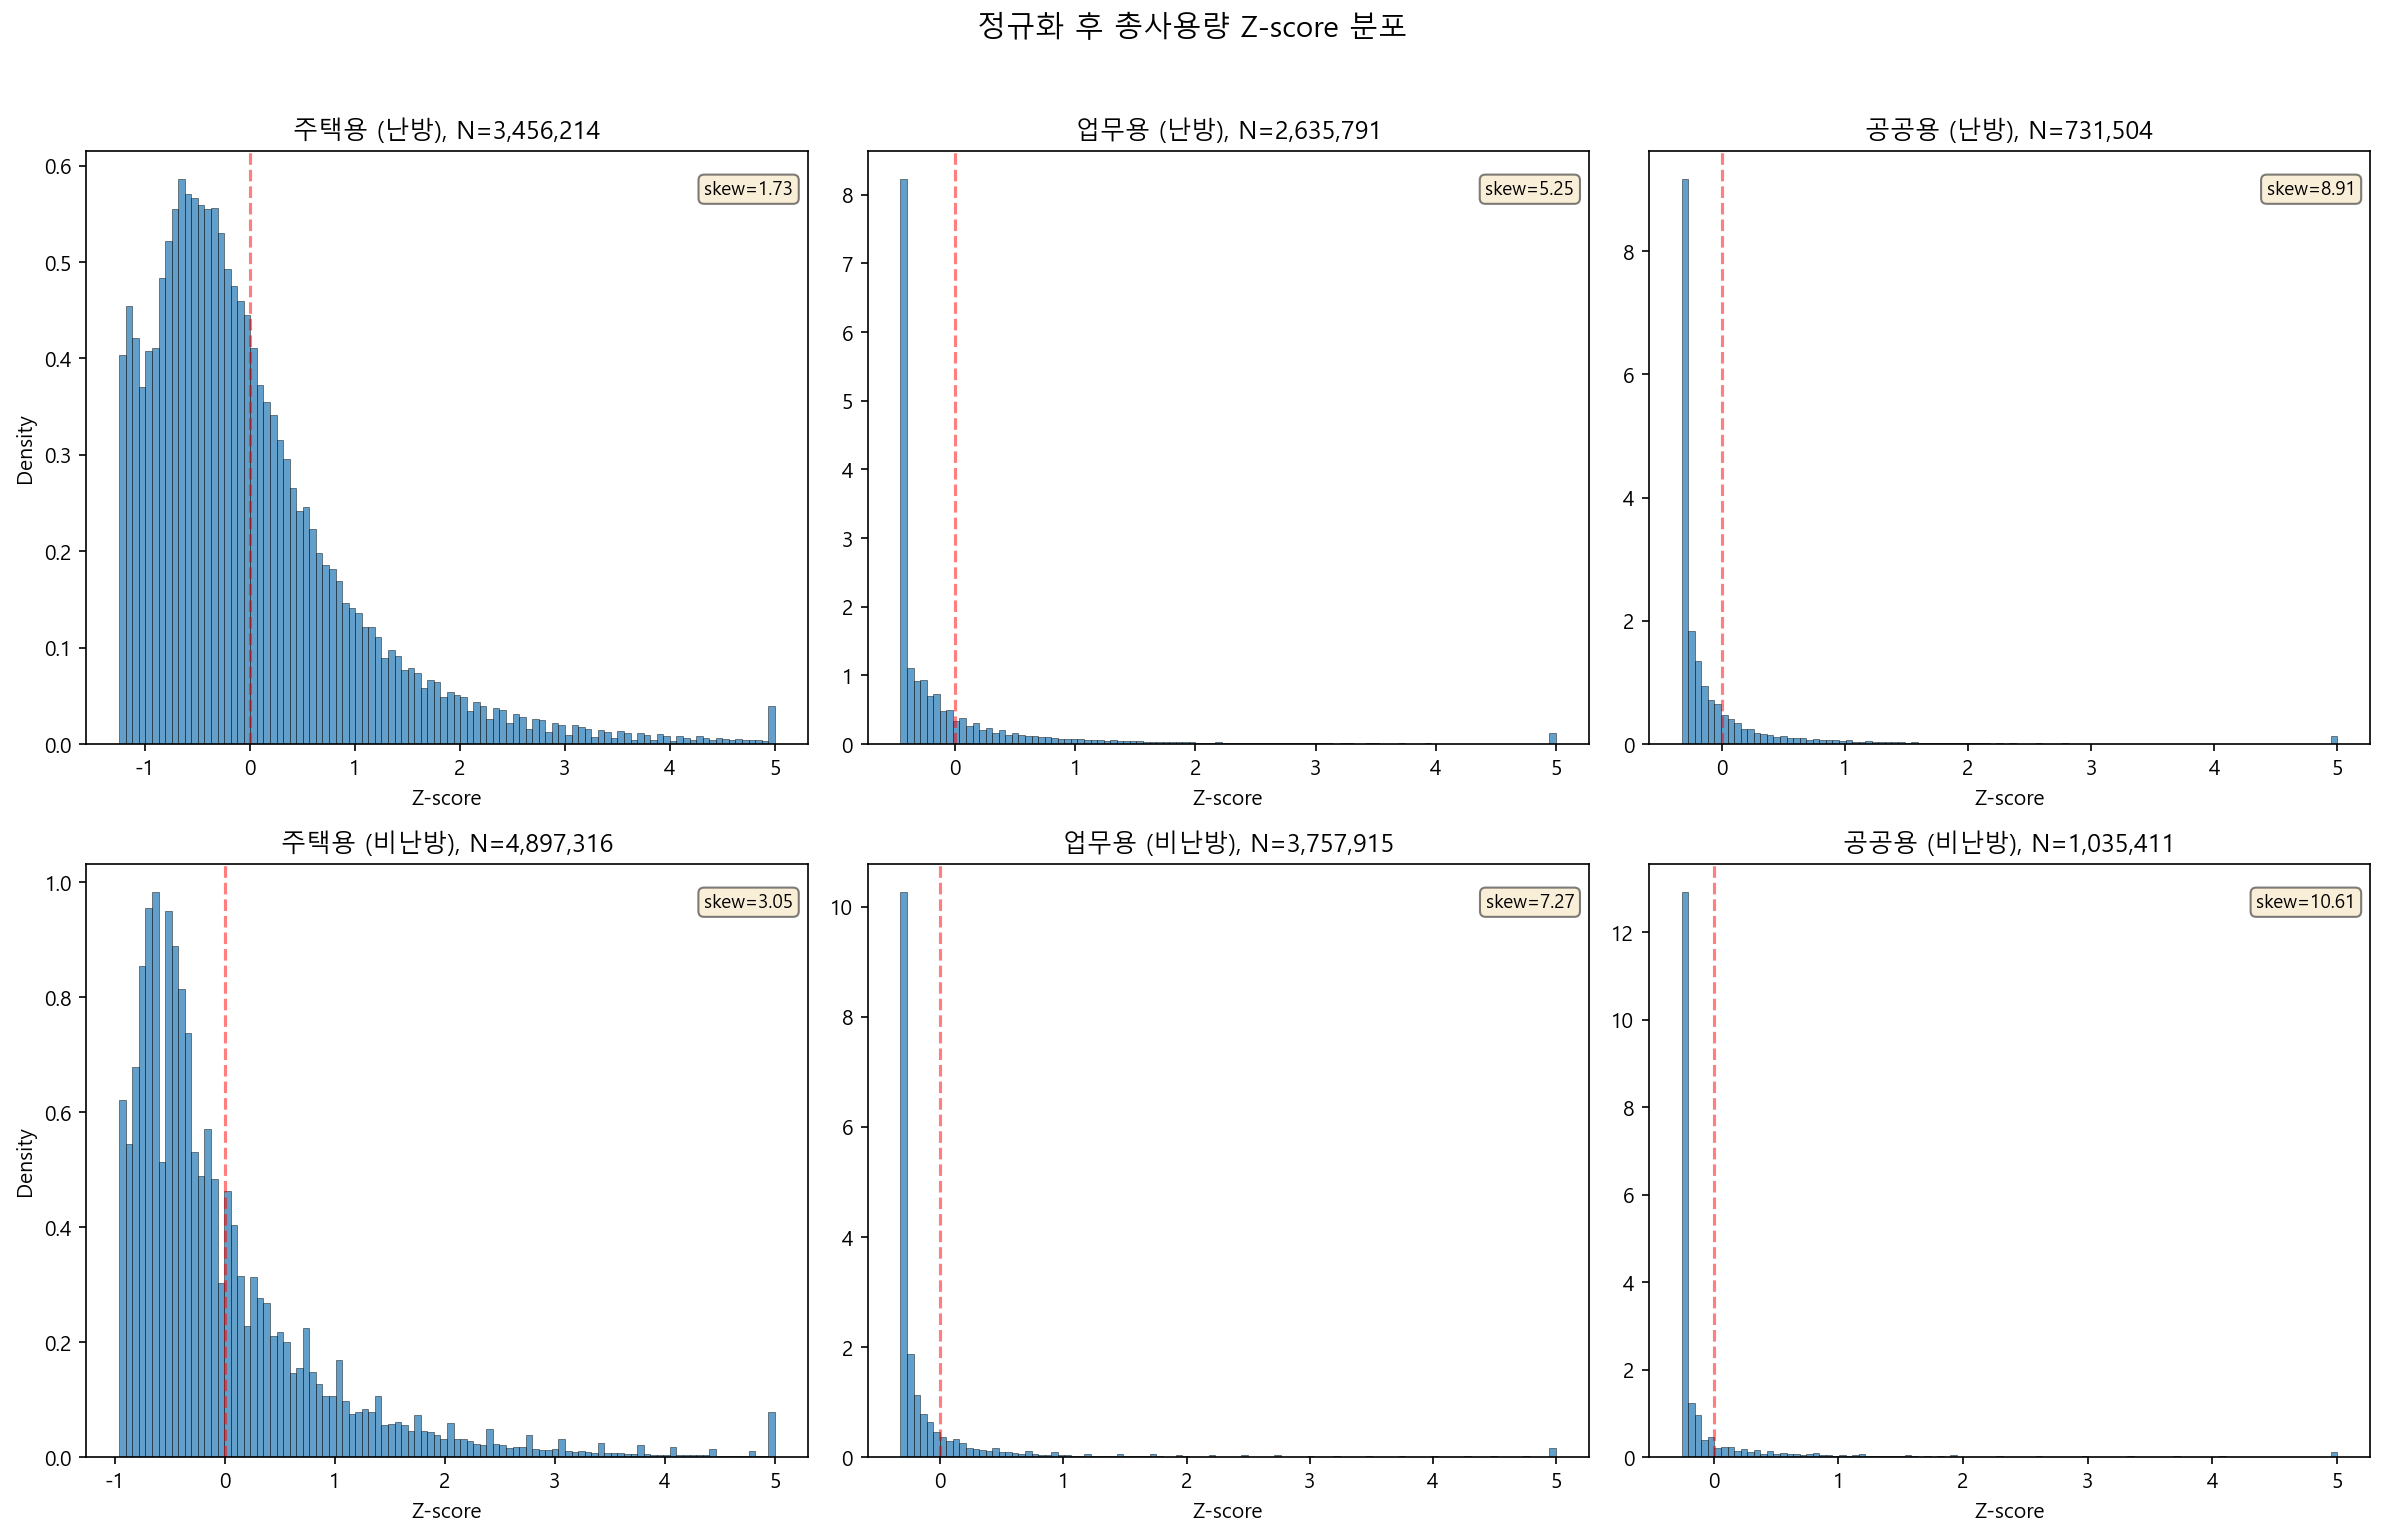

In [5]:
# 정규화 검증: 총사용량 Z-score 분포
df = pd.read_parquet(f'{PROCESSED_DIR}/all_data_clean.parquet', columns=['종별', '난방시즌', '총사용량'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, t in enumerate(['주택용', '업무용', '공공용']):
    for s_idx, (season, s_label) in enumerate([(True, '난방'), (False, '비난방')]):
        ax = axes[s_idx, idx]
        mask = (df['종별'] == t) & (df['난방시즌'] == season)
        key = f'{t}_{s_label}'
        p = norm_params[key]

        vals = df.loc[mask, '총사용량'].values.astype('float64')
        z = (vals - p['mean']['총사용량']) / p['std']['총사용량']
        z_clip = np.clip(z, -5, 5)

        ax.hist(z_clip, bins=100, alpha=0.7, edgecolor='black', linewidth=0.3, density=True)
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_title(f'{t} ({s_label}), N={p["n_rows"]:,}')
        ax.set_xlabel('Z-score')
        if idx == 0:
            ax.set_ylabel('Density')

        skew = float(pd.Series(z).skew())
        ax.text(0.98, 0.95, f'skew={skew:.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('정규화 후 총사용량 Z-score 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase02_normalization_check.png', bbox_inches='tight')
plt.show()
del df

## 지사별 전처리 효과 (극단 CV 지사)

In [6]:
df = pd.read_parquet(f'{PROCESSED_DIR}/all_data_clean.parquet',
                     columns=['종별', '난방시즌', '지사', '총사용량'])
res_h = df[(df['종별'] == '주택용') & (df['난방시즌'] == True)]
stats = res_h.groupby('지사')['총사용량'].agg(['mean', 'median', 'std'])
stats['CV'] = stats['std'] / stats['mean']
stats = stats.sort_values('CV', ascending=False)

print('=== 지사별 주택용 난방시즌 통계 (전처리 후, 상위 10) ===')
print(stats.round(3).head(10).to_string())

for b in ['Branch_0010', 'Branch_0013', 'Branch_0015']:
    if b in stats.index:
        r = stats.loc[b]
        print(f'\n{b}: mean={r["mean"]:.3f}, median={r["median"]:.3f}, CV={r["CV"]:.3f}')
del df, res_h

=== 지사별 주택용 난방시즌 통계 (전처리 후, 상위 10) ===
               mean  median     std     CV
지사                                        
Branch_0008   7.867    6.24   7.433  0.945
Branch_0014   9.594    7.42   8.192  0.854
Branch_0010  10.417    8.65   8.681  0.833
Branch_0006  11.717    8.83   9.676  0.826
Branch_0019  12.591    9.98  10.215  0.811
Branch_0001  13.667   11.10  11.003  0.805
Branch_0003  13.602   11.11  10.879  0.800
Branch_0002  11.001    8.74   8.721  0.793
Branch_0013  11.942    9.89   9.351  0.783
Branch_0011  12.054    9.83   9.370  0.777

Branch_0010: mean=10.417, median=8.650, CV=0.833

Branch_0013: mean=11.942, median=9.890, CV=0.783

Branch_0015: mean=11.683, median=9.930, CV=0.630


## Phase 2 핵심 발견사항 요약

1. **데이터 보존율 97.9%**: 전처리로 인한 손실 최소화. 종별별 제거율 모두 1.3% 이내.
2. **음수값**: 검침기 리셋 1,030행 + 총사용량 음수 1,411행 제거. 시간대 부분 음수 4,667셀은 0 clip.
3. **극단값**: 종별별 시간당 99.9%ile (주택용 2.59, 업무용 2.74, 공공용 4.38 Gcal) 기준 clip. threshold x100 이상 1,324행 제거.
4. **결측치**: NaN=24 60,341행 + NaN 4~23 25,211행 제거. NaN 1~3 88,566행 선형 보간(flag 표시). Branch_0007이 NaN=24 최다(DCU 장애 추정).
5. **정규화**: 종별 x 난방시즌별 Z-score 파라미터 산출 및 저장. 데이터는 원본 스케일 유지.

### 다음 Phase 영향 사항
- Phase 3 Feature Engineering: `all_data_clean.parquet` 기반, 정규화는 `norm_params.json`으로 적용
- `보간` 컬럼으로 보간 행 식별 가능 -> 이상 탐지 시 신뢰도 가중에 활용
- 냉수용 기술통계는 Phase 7 보고서에 별도 기재